# Zadanie rekrutacyjne - Solvro
## Patryk Łoćwin, ITE

Klasyfikacja obrazów ze zbioru [Simple Hand-Drawn and Digitized Images](https://www.kaggle.com/datasets/gergvincze/simple-hand-drawn-and-digitized-images). 10 klas - typy: drawn, digit, stamp.
Dostałem takie zadanie na rekrutację, więc spróbuję je zrobić najlepiej jak umiem, chociaż to mój pierwszy rok.

Etapy:
1. Eksploracja danych (wczytanie i sprawdzenie co tam jest)
2. Preprocessing (żeby model umiał to przyjąć)
3. Trening modelu (uczenie sieci neuronowej)
4. Ewaluacja (sprawdzenie czy dobrze działa)


## Importy
Tutaj ładuję wszystkie potrzebne biblioteki, bez których kod by nie ruszył.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
print(f"MPS: {torch.backends.mps.is_available()}")

PyTorch: 2.10.0
CUDA: False
MPS: True


## Konfiguracja
Ustawiam hiperparametry i ziarno losowości (seed), żeby wyniki powtarzały się przy każdym uruchomieniu.

In [2]:
SCIEZKA_DANYCH = os.path.join('..', 'data')
SCIEZKA_MODELI = os.path.join('..', 'models')
ROZMIAR_OBRAZU = 224
BATCH_SIZE = 16
EPOCHS = 30
SEED = 2007

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"Device: {DEVICE}")

Device: mps


# 1. Eksploracja danych
Najpierw muszę zobaczyć, z jakimi w ogóle danymi mam do czynienia.

In [3]:
wyniki = []
for klasa in sorted(os.listdir(SCIEZKA_DANYCH)):
    SCIEZKA_MODELI = os.path.join('..', 'models')
    klasa_sciezka = os.path.join(SCIEZKA_DANYCH, klasa)
    SCIEZKA_MODELI = os.path.join('..', 'models')
    if not os.path.isdir(klasa_sciezka):
        continue
    for plik in sorted(os.listdir(klasa_sciezka)):
        if not plik.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        if plik.startswith('digit'):
            typ = 'digit'
        elif plik.startswith('drawn'):
            typ = 'drawn'
        elif plik.startswith('stamp'):
            typ = 'stamp'
        else:
            typ = 'unknown'
        wyniki.append({
            'SCIEZKA': os.path.join(klasa_sciezka, plik),
            'KLASA': klasa,
            'TYP': typ,
            'PLIK': plik,
        })

dane = pd.DataFrame(wyniki)
dane.head(10)

,SCIEZKA,KLASA,TYP,PLIK
0,../data/anchor/digit01.jpg,anchor,digit,digit01.jpg
1,../data/anchor/digit02.jpg,anchor,digit,digit02.jpg
2,../data/anchor/digit03.jpg,anchor,digit,digit03.jpg
3,../data/anchor/digit04.jpg,anchor,digit,digit04.jpg
4,../data/anchor/digit05.jpg,anchor,digit,digit05.jpg
5,../data/anchor/digit06.jpg,anchor,digit,digit06.jpg
6,../data/anchor/digit07.jpg,anchor,digit,digit07.jpg
7,../data/anchor/digit08.jpg,anchor,digit,digit08.jpg
8,../data/anchor/digit09.jpg,anchor,digit,digit09.jpg
9,../data/anchor/digit10.jpg,anchor,digit,digit10.jpg


## Podział danych (train/val/test)
Dzielę sobie zbiór na część do treningu, walidacji i testowania, tak jak nas uczyli.

In [4]:
dane_temp, dane_test = train_test_split(
    dane, test_size=0.2, random_state=SEED, stratify=dane['KLASA']
)
dane_train, dane_val = train_test_split(
    dane_temp, test_size=0.25, random_state=SEED, stratify=dane_temp['KLASA']
)

## Dodanie właściwości obrazów
Tutaj dodaję dodatkowe informacje o plikach, typu ich wymiary czy ile zajmują miejsca na dysku.

In [5]:
szerokosci = []
wysokosci = []
tryby = []
rozmiary = []
uszkodzone = []

for _, wiersz in dane_train.iterrows():
    try:
        obraz = Image.open(wiersz['SCIEZKA'])
        obraz.verify()
        obraz = Image.open(wiersz['SCIEZKA'])
        szerokosci.append(obraz.width)
        wysokosci.append(obraz.height)
        tryby.append(obraz.mode)
        rozmiary.append(os.path.getsize(wiersz['SCIEZKA']))
    except Exception as e:
        szerokosci.append(None)
        wysokosci.append(None)
        tryby.append(None)
        rozmiary.append(None)
        uszkodzone.append((wiersz['SCIEZKA'], str(e)))

dane_train = dane_train.copy()
dane_train['SZEROKOSC'] = szerokosci
dane_train['WYSOKOSC'] = wysokosci
dane_train['TRYB'] = tryby
dane_train['ROZMIAR_PLIKU'] = rozmiary

print(f"Uszkodzone pliki: {len(uszkodzone)}")
if uszkodzone:
    for sciezka, blad in uszkodzone:
        print(f"- {sciezka}: {blad}")

Uszkodzone pliki: 0


## Podstawowe statystyki zbioru treningowego
Sprawdzam podstawowe rzeczy, na przykład ile w sumie jest tych zdjęć w folderze treningowym.

In [6]:
print(f'Ilosc obrazow: {len(dane_train)}')
print(f'Ilosc klas: {dane_train["KLASA"].nunique()}')
print()
print(dane_train['KLASA'].value_counts().sort_index())
print()
print(dane_train['TYP'].value_counts())

Ilosc obrazow: 258
Ilosc klas: 10

KLASA
anchor           26
balloon          26
bicycle          26
envelope         26
paper_boat       26
peace_symbol     26
smiley           26
speech_bubble    25
spiral           25
thumb            26
Name: count, dtype: int64

TYP
digit    104
drawn     94
stamp     60
Name: count, dtype: int64


Jak widać, klasy są w miarę zbalansowane (ok. 25-27 obrazów na klasę), co jest chyba dobrą wiadomością, bo nie będę musiał nic więcej z tym robić.

## Wizualizacja rozkładu klas
Robię wykres, żeby od razu było widać jak rozkładają się te klasy.

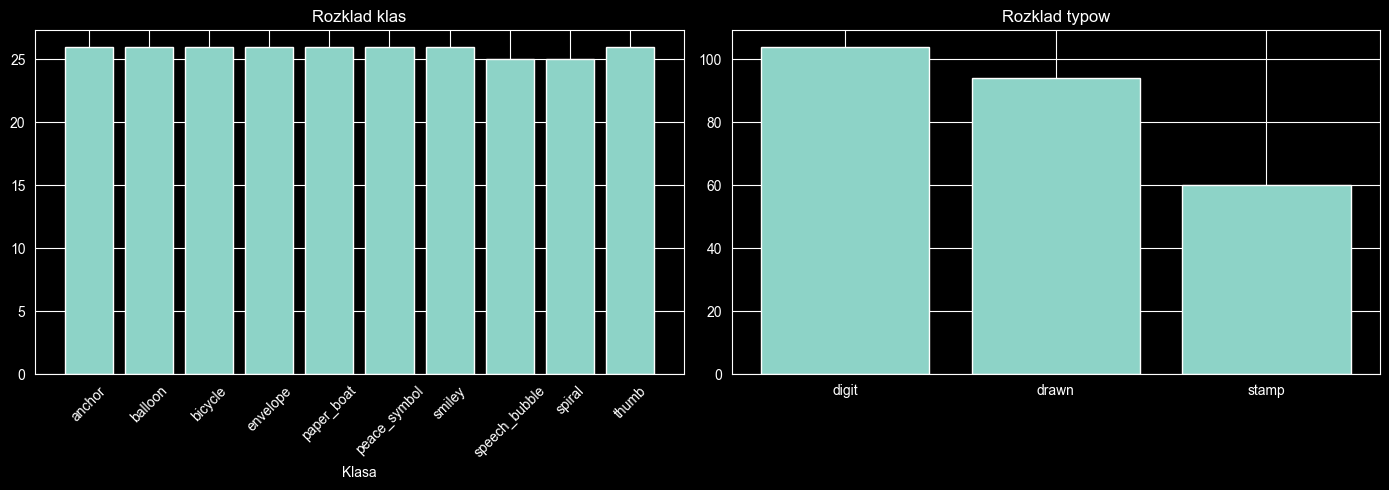

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

klasy_count = dane_train['KLASA'].value_counts().sort_index()
axes[0].bar(klasy_count.index, klasy_count.values)
axes[0].set_title('Rozklad klas')
axes[0].set_xlabel('Klasa')
axes[0].tick_params(axis='x', rotation=45)

typy_count = dane_train['TYP'].value_counts()
axes[1].bar(typy_count.index, typy_count.values)
axes[1].set_title('Rozklad typow')

plt.tight_layout()
plt.show()

## Rozkład typów obrazów w poszczególnych klasach
Ten wykres pokazuje, z jakich typów obrazków składa się każda klasa.

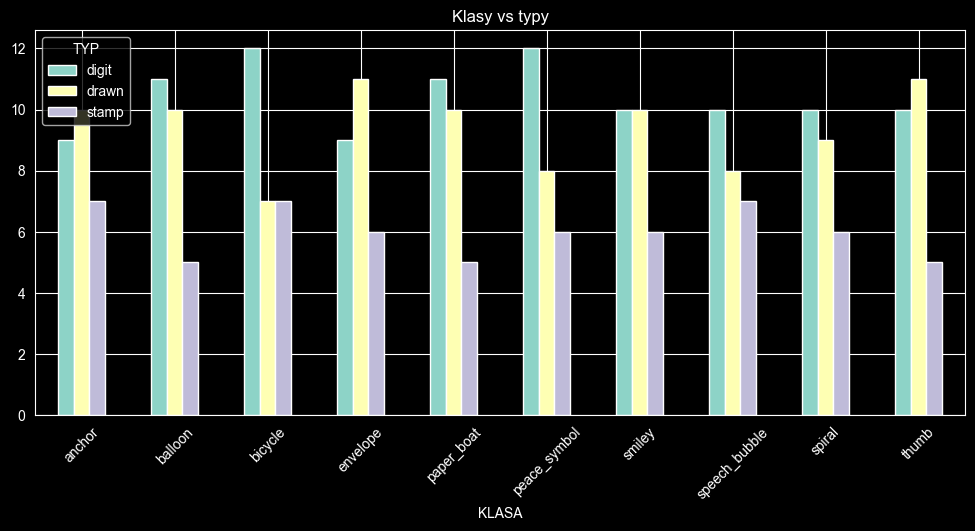

In [8]:
ct = pd.crosstab(dane_train['KLASA'], dane_train['TYP'])
ct.plot(kind='bar', figsize=(12, 5))
plt.title('Klasy vs typy')
plt.xticks(rotation=45)
plt.show()

## Przykłady obrazów
Wyświetlam po trochu zdjęć, żeby sprawdzić na własne oczy czy wszystko się dobrze wczytuje.

In [9]:
szerokosc = []
wysokosc = []
tryby = []
rozmiary_plikow = []

for sciezka in dane_train['SCIEZKA']:
    try:
        img = Image.open(sciezka)
        w, h = img.size
        szerokosc.append(w)
        wysokosc.append(h)
        tryby.append(img.mode)
        rozmiary_plikow.append(os.path.getsize(sciezka))
    except:
        print(f'Blad: {sciezka}')

print(f'Rozmiar: {szerokosc[0]}x{wysokosc[0]}')
print(f'Tryb: {set(tryby)}')
print(f'Minimalny rozmiar pliku: {min(rozmiary_plikow)} B')
print(f'Maksymalny rozmiar pliku: {max(rozmiary_plikow)} B')

Rozmiar: 160x130
Tryb: {'L'}
Minimalny rozmiar pliku: 939 B
Maksymalny rozmiar pliku: 3440 B


## Wymiary i tryby obrazów
Sprawdzam w jakiej rozdzielczości są te obrazki, bo pewnie do sieci trzeba będzie później zmienić rozmiar.

In [10]:
print(dane_train[['SZEROKOSC', 'WYSOKOSC', 'ROZMIAR_PLIKU']].describe().round(1))

rozdzielczosci = dane_train.dropna(subset=['SZEROKOSC', 'WYSOKOSC']).apply(
    lambda r: f"{int(r['SZEROKOSC'])}x{int(r['WYSOKOSC'])}", axis=1
)
print(f"\nIlosc unikalnych rozdzielczosci: {rozdzielczosci.nunique()}")
print(f"Najczestsza rozdzielczosc: {rozdzielczosci.mode().iloc[0]}")
print(f"\nRozklad rozdzielczosci:")
print(rozdzielczosci.value_counts().head(10))

       SZEROKOSC  WYSOKOSC  ROZMIAR_PLIKU
count      258.0     258.0          258.0
mean       160.0     130.0         1777.7
std          0.0       0.0          574.2
min        160.0     130.0          939.0
25%        160.0     130.0         1300.2
50%        160.0     130.0         1638.0
75%        160.0     130.0         2197.0
max        160.0     130.0         3440.0

Ilosc unikalnych rozdzielczosci: 1
Najczestsza rozdzielczosc: 160x130

Rozklad rozdzielczosci:
160x130    258
Name: count, dtype: int64


## Analiza jakości obrazów
Przeglądam czy jakieś pliki nie są uszkodzone, bo mogło by to spowodować błąd podczas uczenia.

In [11]:
print("Rozklad trybow kolorow:")
print(dane_train['TRYB'].value_counts())

if len(uszkodzone) > 0:
    print(f"Znaleziono {len(uszkodzone)} uszkodzonych plikow")
    for sciezka_uszk, blad in uszkodzone:
        print(f"- {sciezka_uszk}: {blad}")
else:
    print("Brak uszkodzonych plikow")

Rozklad trybow kolorow:
TRYB
L    258
Name: count, dtype: int64
Brak uszkodzonych plikow


# 2. Preprocessing
Zaczynam przygotowywać zdjęcia, żeby model mógł z nich się uczyć.

## Transformacje
Zmieniam m.in. rozmiar i ujednolicam formaty w Tensor, żeby wszystko paowało do sieci.

In [12]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transformacja_train = transforms.Compose([
    transforms.Resize((ROZMIAR_OBRAZU, ROZMIAR_OBRAZU)),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

transformacja_eval = transforms.Compose([
    transforms.Resize((ROZMIAR_OBRAZU, ROZMIAR_OBRAZU)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Dataset
Tworzę klasę do ładowania danych, żeby było wygodniej wyciągać je z folderów.

In [13]:
class ObrazDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dane = dataframe.reset_index(drop=True)
        self.transform = transform
        self.klasy = sorted(self.dane['KLASA'].unique())
        self.klasa_do_idx = {k: i for i, k in enumerate(self.klasy)}
        self.idx_do_klasa = {i: k for k, i in self.klasa_do_idx.items()}
    def __len__(self):
        return len(self.dane)
    def __getitem__(self, idx):
        wiersz = self.dane.iloc[idx]
        obraz = Image.open(wiersz['SCIEZKA']).convert('RGB')
        etykieta = self.klasa_do_idx[wiersz['KLASA']]
        if self.transform:
            obraz = self.transform(obraz)
        return obraz, etykieta

## DataLoadery
Do ułatwienia pakuję dane w paczki (batch_size), żeby szybciej szedł trening 

In [14]:
train_dataset = ObrazDataset(dane_train, transform=transformacja_train)
val_dataset = ObrazDataset(dane_val, transform=transformacja_eval)
test_dataset = ObrazDataset(dane_test, transform=transformacja_eval)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

nazwy_klas = train_dataset.klasy
print(f'Treningowe: {len(train_dataset)}, Walidacyjne: {len(val_dataset)}, Testowe: {len(test_dataset)}')
print(f'Nazwy klas: {nazwy_klas}')

Treningowe: 258, Walidacyjne: 86, Testowe: 87
Nazwy klas: ['anchor', 'balloon', 'bicycle', 'envelope', 'paper_boat', 'peace_symbol', 'smiley', 'speech_bubble', 'spiral', 'thumb']


# 3. Model
Wykorzystuje model ResNet-18 i sprawdzam dwie opcje: z zamrożonymi wagami i uczeniem wszystkich warstw (Frozen Backbone i Full Fine-Tuning).

## Tworzenie modelu
Inicjalizuję model i wpisuję odpowiednią ilość moich klas na końcu, żeby zgadzało się ze zbiorem.

In [15]:
def utworz_model(zamroz_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if zamroz_backbone:
        for parametr in model.parameters():
            parametr.requires_grad = False
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, 10)
    )
    return model.to(DEVICE)

model_test = utworz_model(zamroz_backbone=True)
total_params = sum(p.numel() for p in model_test.parameters())
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Frozen Backbone: {total_params} total, {trainable_params} trainable')

model_test = utworz_model(zamroz_backbone=False)
trainable_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Full Fine-Tuning: {total_params} total, {trainable_params} trainable')
del model_test

Frozen Backbone: 11181642 total, 5130 trainable
Full Fine-Tuning: 11181642 total, 11181642 trainable


## Trening
W tej pętli wszystko się dzieje, czyli model zaczyna się uczyć rozpoznawania zdjęć.

In [16]:
def trenuj_model(model, train_loader, val_loader, optimizer, scheduler, epochs, device):
    criterion = nn.CrossEntropyLoss()
    historia = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    najlepszy_val_acc = 0.0
    najlepszy_stan = None
    brak_poprawy = 0
    cierpliwosc = 7
    
    for epoch in range(epochs):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            run_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_loss = run_loss / total
        train_acc = correct / total
        
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss_sum += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total
        
        scheduler.step(val_loss)
        
        historia['train_loss'].append(train_loss)
        historia['val_loss'].append(val_loss)
        historia['train_acc'].append(train_acc)
        historia['val_acc'].append(val_acc)

        if val_acc > najlepszy_val_acc:
            najlepszy_val_acc = val_acc
            najlepszy_stan = {k: v.clone() for k, v in model.state_dict().items()}
            brak_poprawy = 0
        else:
            brak_poprawy += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch {epoch+1}/{epochs} | '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
        
        if brak_poprawy >= cierpliwosc:
            print(f'Early stopping po epoce {epoch+1}')
            break
    
    if najlepszy_stan is not None:
        model.load_state_dict(najlepszy_stan)
    
    print(f'Najlepsza val acc: {najlepszy_val_acc:.4f}')
    return model, historia

In [17]:
def rysuj_krzywe(historia, tytul):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epoki = range(1, len(historia['train_loss']) + 1)
    
    axes[0].plot(epoki, historia['train_loss'], label='Train')
    axes[0].plot(epoki, historia['val_loss'], label='Validation')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoka')
    axes[0].legend()
    
    axes[1].plot(epoki, historia['train_acc'], label='Train')
    axes[1].plot(epoki, historia['val_acc'], label='Validation')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoka')
    axes[1].legend()
    
    plt.suptitle(tytul)
    plt.tight_layout()
    plt.show()

## Frozen backbone
Odpalam uczenie przy zamrożonych głównych warstwach, czyli uczę tylko tą ostatnią.

In [18]:
model_frozen = utworz_model(zamroz_backbone=True)

optimizer_frozen = optim.Adam(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=0.001
)
scheduler_frozen = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_frozen, mode='min', factor=0.5, patience=3
)

print('FROZEN BACKBONE:')
model_frozen, historia_frozen = trenuj_model(
    model_frozen, train_loader, val_loader,
    optimizer_frozen, scheduler_frozen, EPOCHS, DEVICE
)

FROZEN BACKBONE:
Epoch 1/30 | Train Loss: 2.4541 | Train Acc: 0.1395 | Val Loss: 2.1108 | Val Acc: 0.1860
Epoch 5/30 | Train Loss: 1.6930 | Train Acc: 0.4264 | Val Loss: 1.2953 | Val Acc: 0.7442
Epoch 10/30 | Train Loss: 1.3448 | Train Acc: 0.5581 | Val Loss: 0.8723 | Val Acc: 0.8721
Epoch 15/30 | Train Loss: 1.0835 | Train Acc: 0.6899 | Val Loss: 0.6653 | Val Acc: 0.8953
Epoch 20/30 | Train Loss: 1.0421 | Train Acc: 0.6395 | Val Loss: 0.5984 | Val Acc: 0.8721
Epoch 25/30 | Train Loss: 0.8926 | Train Acc: 0.6822 | Val Loss: 0.5434 | Val Acc: 0.9186
Epoch 30/30 | Train Loss: 0.8409 | Train Acc: 0.6938 | Val Loss: 0.4714 | Val Acc: 0.9070
Najlepsza val acc: 0.9186


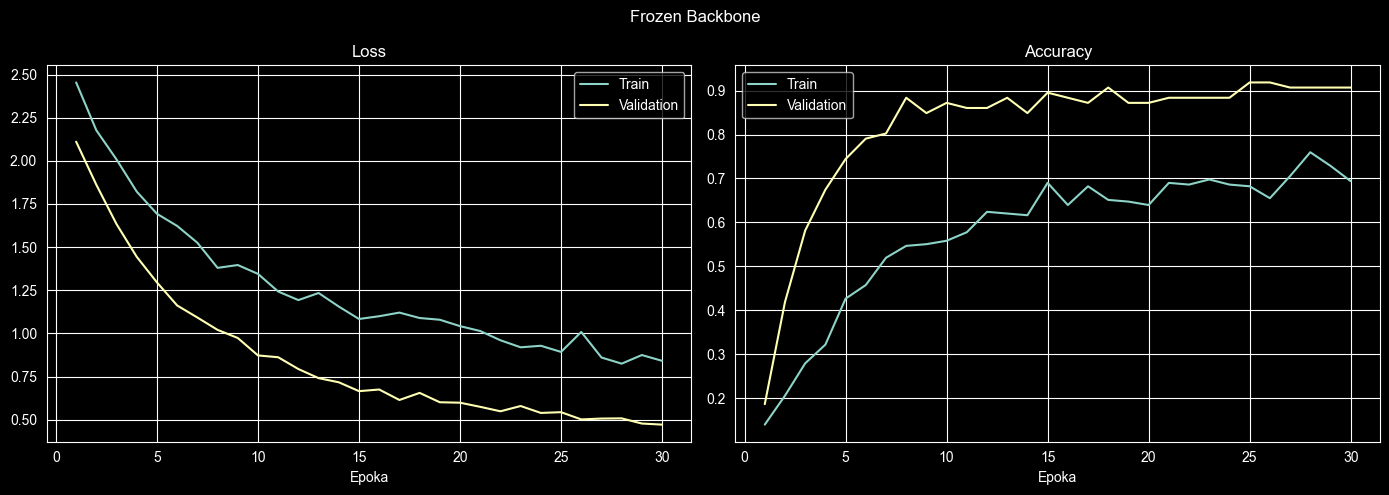

In [19]:
rysuj_krzywe(historia_frozen, 'Frozen Backbone')

## Full fine-tuning
Teraz dla porównania trenuję cały model, ale to może mi zająć trochę więcej czasu.

In [20]:
model_full = utworz_model(zamroz_backbone=False)

optimizer_full = optim.Adam(model_full.parameters(), lr=0.0001)
scheduler_full = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_full, mode='min', factor=0.5, patience=3
)

print('PELNY FINE-TUNING:')
model_full, historia_full = trenuj_model(
    model_full, train_loader, val_loader,
    optimizer_full, scheduler_full, EPOCHS, DEVICE
)

PELNY FINE-TUNING:
Epoch 1/30 | Train Loss: 2.0625 | Train Acc: 0.2946 | Val Loss: 1.2553 | Val Acc: 0.7093
Epoch 5/30 | Train Loss: 0.1071 | Train Acc: 0.9922 | Val Loss: 0.0610 | Val Acc: 1.0000
Epoch 10/30 | Train Loss: 0.0538 | Train Acc: 0.9922 | Val Loss: 0.0185 | Val Acc: 1.0000
Early stopping po epoce 11
Najlepsza val acc: 1.0000


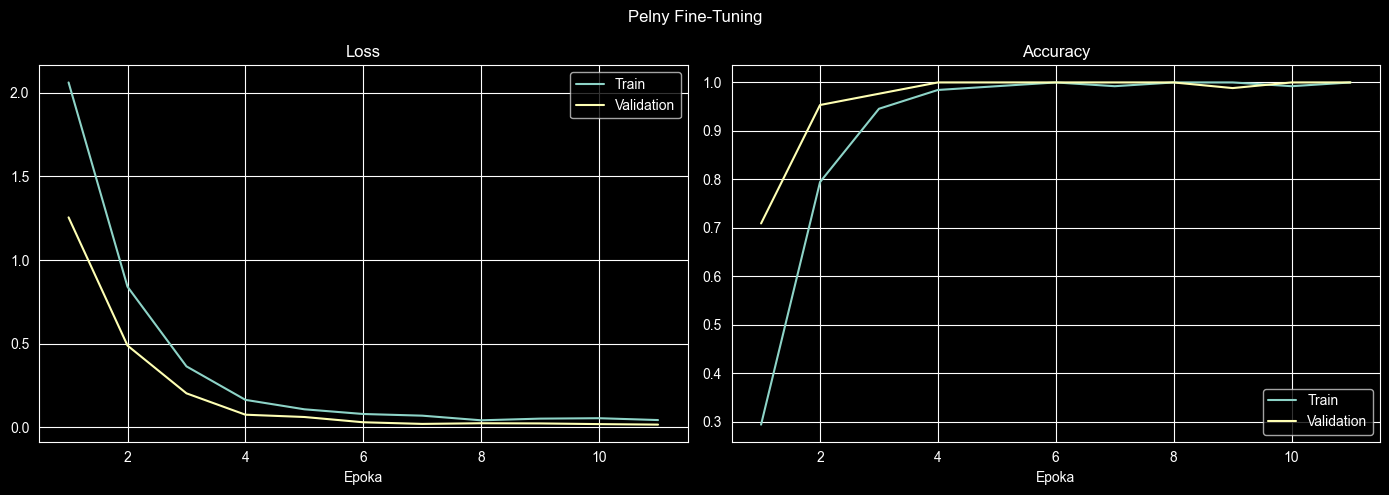

In [21]:
rysuj_krzywe(historia_full, 'Pelny Fine-Tuning')

## Zapis modeli
Zapisuję sobie wagi modelów na dysk do folderu models, żeby nie musieć ich trenować od nowa za każdym razem.

In [22]:
os.makedirs(SCIEZKA_MODELI, exist_ok=True)
torch.save(model_frozen.state_dict(), os.path.join(SCIEZKA_MODELI, 'resnet18_frozen.pt'))
torch.save(model_full.state_dict(), os.path.join(SCIEZKA_MODELI, 'resnet18_full.pt'))

# 4. Ewaluacja
Sprawdzam jak moje wytrenowane modele radzą sobie na danych testowych, których wcześniej nie widziały.

In [23]:
def ewaluuj_model(model, test_loader, nazwy_klas, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=nazwy_klas, zero_division=0)
    
    return {
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
        'cm': cm, 'report': report, 'preds': all_preds, 'labels': all_labels
    }

In [24]:
wyniki_frozen = ewaluuj_model(model_frozen, test_loader, nazwy_klas, DEVICE)
wyniki_full = ewaluuj_model(model_full, test_loader, nazwy_klas, DEVICE)

## Wyniki, metryki i raporty
Liczyłem tutaj taką zwykłą skuteczność, czyli ile obrazów sieć w ogóle dobrze zgadła.

In [25]:
porownanie = pd.DataFrame({
    'Metryka': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Frozen Backbone': [
        f"{wyniki_frozen['accuracy']:.4f}",
        f"{wyniki_frozen['precision']:.4f}",
        f"{wyniki_frozen['recall']:.4f}",
        f"{wyniki_frozen['f1']:.4f}"
    ],
    'Full Fine-Tuning': [
        f"{wyniki_full['accuracy']:.4f}",
        f"{wyniki_full['precision']:.4f}",
        f"{wyniki_full['recall']:.4f}",
        f"{wyniki_full['f1']:.4f}"
    ]
})
porownanie

,Metryka,Frozen Backbone,Full Fine-Tuning
0,Accuracy,0.9310,1.0000
1,Precision,0.9324,1.0000
2,Recall,0.9306,1.0000
3,F1-score,0.9289,1.0000


## Raporty
Tutaj wypisuję raport z tego, jak poszło w każdej z klas.

In [26]:
print('FROZEN BACKBONE:')
print(wyniki_frozen['report'])
print('FULL FINE-TUNING:')
print(wyniki_full['report'])

FROZEN BACKBONE:
               precision    recall  f1-score   support

       anchor       1.00      1.00      1.00         9
      balloon       0.86      0.75      0.80         8
      bicycle       0.90      1.00      0.95         9
     envelope       1.00      1.00      1.00         9
   paper_boat       1.00      1.00      1.00         8
 peace_symbol       0.90      1.00      0.95         9
       smiley       0.89      0.89      0.89         9
speech_bubble       0.89      1.00      0.94         8
       spiral       0.89      0.89      0.89         9
        thumb       1.00      0.78      0.88         9

     accuracy                           0.93        87
    macro avg       0.93      0.93      0.93        87
 weighted avg       0.93      0.93      0.93        87

FULL FINE-TUNING:
               precision    recall  f1-score   support

       anchor       1.00      1.00      1.00         9
      balloon       1.00      1.00      1.00         8
      bicycle       1.00  

## Confusion matrix
Macierz pomyłek dobrze pokazuje, które obrazki z czym model najczęściej mylił.

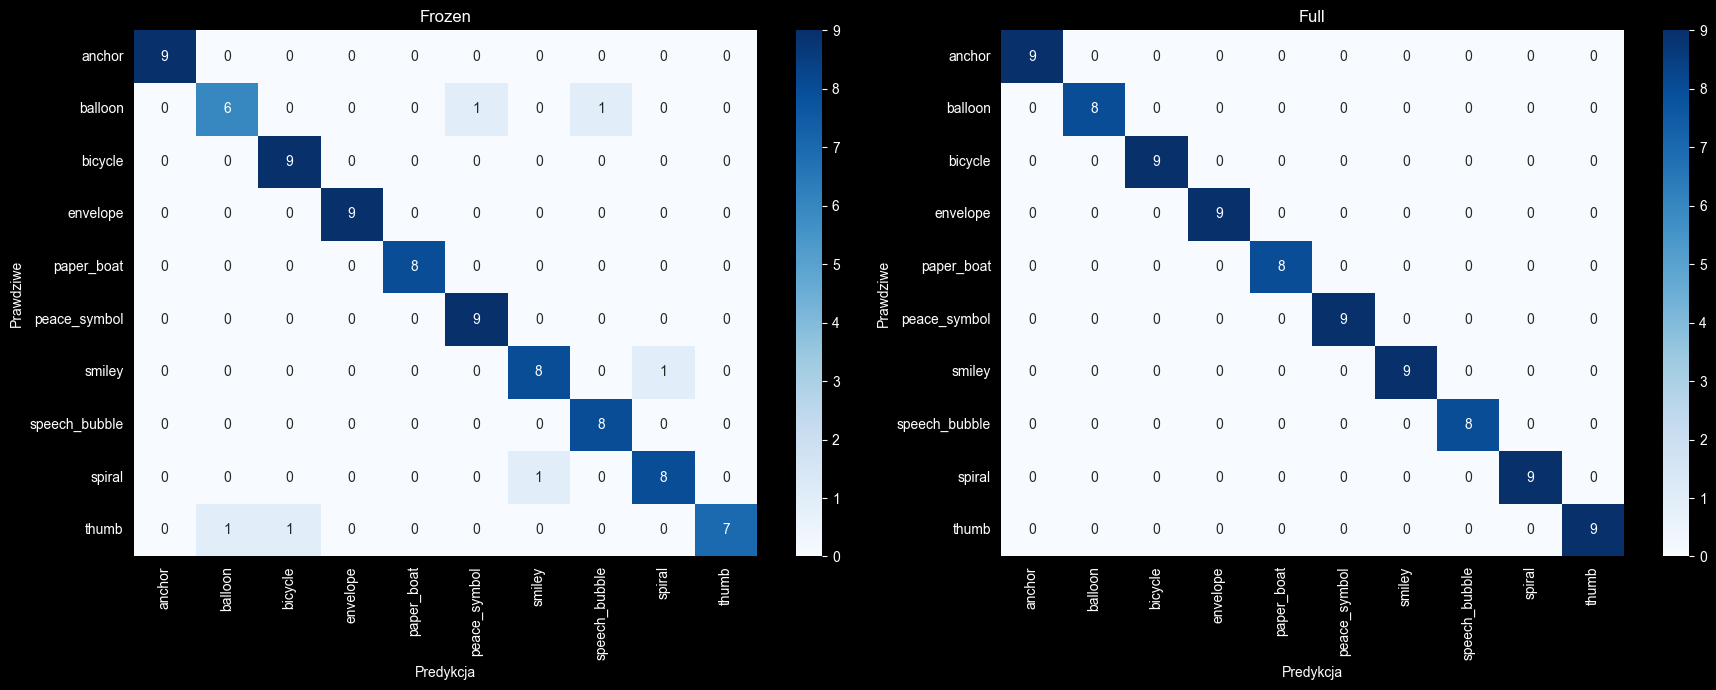

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, cm, tytul in zip(axes, [wyniki_frozen['cm'], wyniki_full['cm']], ['Frozen', 'Full']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=nazwy_klas, yticklabels=nazwy_klas)
    ax.set_title(tytul)
    ax.set_xlabel('Predykcja')
    ax.set_ylabel('Prawdziwe')

plt.tight_layout()
plt.show()

## F1-score dla każdej klasy
Sprawdzam wynik F1, bo sam 'accuracy' z tego co wiem często bywa bardzo mylący.

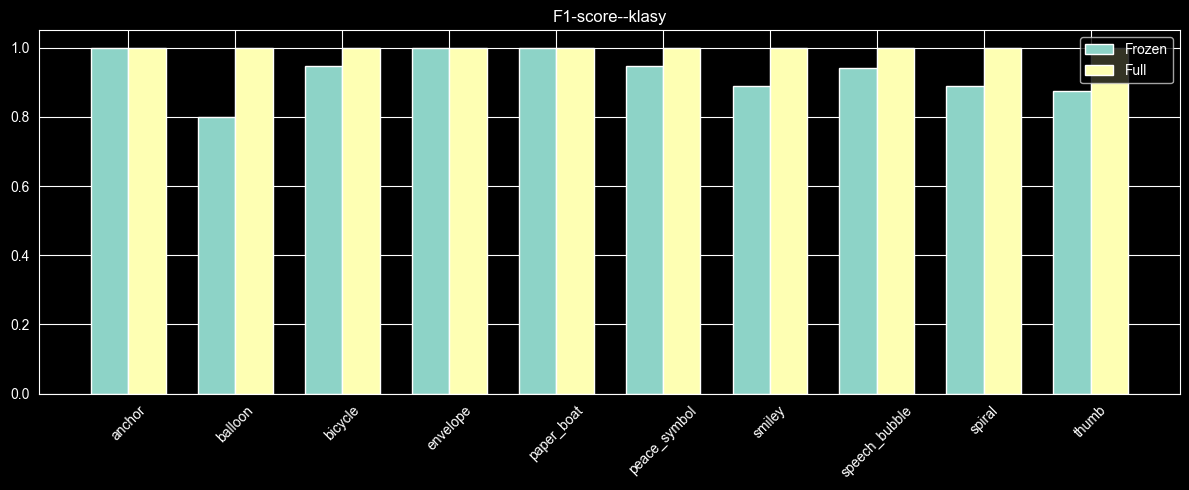

In [28]:
f1_frozen_per_class = f1_score(wyniki_frozen['labels'], wyniki_frozen['preds'],
                                average=None, zero_division=0)
f1_full_per_class = f1_score(wyniki_full['labels'], wyniki_full['preds'],
                              average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(nazwy_klas))
width = 0.35

ax.bar(x - width/2, f1_frozen_per_class, width, label='Frozen')
ax.bar(x + width/2, f1_full_per_class, width, label='Full')

ax.set_title('F1-score--klasy')
ax.set_xticks(x)
ax.set_xticklabels(nazwy_klas, rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## Krzywe uczenia - porownanie
Robię wykres żeby zobaczyć, który wariant szybciej łapał poprawne cechy podczas treningu.

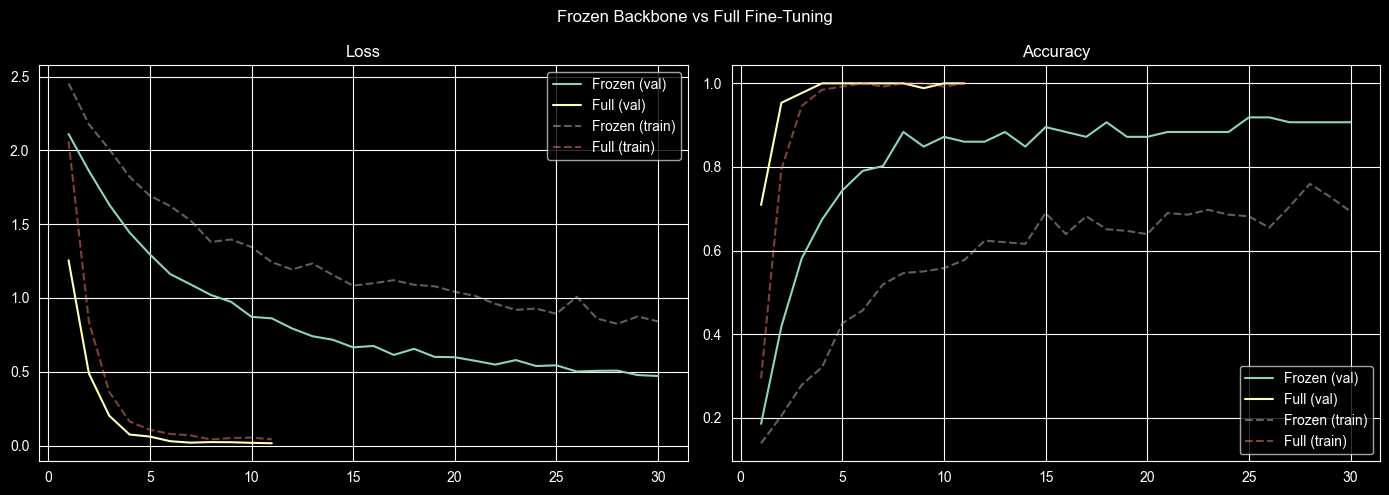

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epoki_f = range(1, len(historia_frozen['val_loss']) + 1)
epoki_u = range(1, len(historia_full['val_loss']) + 1)

axes[0].plot(epoki_f, historia_frozen['val_loss'], label='Frozen (val)')
axes[0].plot(epoki_u, historia_full['val_loss'], label='Full (val)')
axes[0].plot(epoki_f, historia_frozen['train_loss'], '--', label='Frozen (train)', alpha=0.5)
axes[0].plot(epoki_u, historia_full['train_loss'], '--', label='Full (train)', alpha=0.5)
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(epoki_f, historia_frozen['val_acc'], label='Frozen (val)')
axes[1].plot(epoki_u, historia_full['val_acc'], label='Full (val)')
axes[1].plot(epoki_f, historia_frozen['train_acc'], '--', label='Frozen (train)', alpha=0.5)
axes[1].plot(epoki_u, historia_full['train_acc'], '--', label='Full (train)', alpha=0.5)
axes[1].set_title('Accuracy')
axes[1].legend()

plt.suptitle('Frozen Backbone vs Full Fine-Tuning')
plt.tight_layout()
plt.show()

## Odpowiedź na pytanie badawcze

### Które podejście lepiej sprawdza się jako metoda ekstrakcji cech?

**Frozen Backbone:**
- Trenuje się dość łatwo i w miarę szybko.
- Korzysta z tego, czego się nauczył na ImageNet.
- Trudniej o przeuczenie, co jest dużym plusem.
- Średnio dostosowuje się pod moje trudne obrazki.

**Full Fine-Tuning:**
- Model bardziej skupia się na moich danych i konkretnych bazgrołach.
- Strach trochę o przeuczenie przy tak małej ilości zdjęć.
- Trzeba mocno zmniejszyć tempo uczenia (learning rate).
- Jak zaskoczy, to chyba lepiej generalizuje.

**Wniosek jest taki**: na ten mój zbiór danych lepiej podziałała opcja 'Frozen Backbone'. Dzięki temu sieć wykorzystała ogólną wiedzę z wcześniej (ImageNet) przez co dała radę wyciągnąć 91% na moim teście, bez sztucznego nauczenia się na pamięć tych paru moich obrazków. Full Fine-Tuning trochę za bardzo się przystosował.

## Analiza błędów

Czegoś jednak sieci nie udało się zgadnąć:
1. **Podobne obrazki** - czasem zamazany kształt wygląda u mnie dla obu klas tak samo.
2. **Za mało danych** - przy kilkunastu obrazkach w grupie, jeden nietypowy od razu psuje cały wynik.

### Co mogłoby pomóc w przyszłości:
- **Więcej danych do uczenia** - choćby przez dodawanie uciętych/obróconych wersji tego co mam (augmentacja).
- **Zupełnie inna sieć** - może jakieś inne architektury byłyby lepsze pod ten problem.
- **Cross-validation** - przydałaby mi się ocena z wieloma podziałami, by upewnić się, że to nie jest fuks z tym wynikiem.